<a href="https://colab.research.google.com/github/hidalgogo/Actividad-NLP---Sistema-inteligente-para-b-squeda-de-talento/blob/main/1_basic_operations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Simple Image Operations

## Table of Contents
1. [Libraries](#libraries)
2. [Loading Images](#loading)
3. [Resizing Images](#resize)
4. [Negative Images](#negative)
5. [Logarithmic Transformation](#log)
6. [Image Binarizer](#bin)
7. [Image Quantizer](#quant)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [2]:
from matplotlib import image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import cv2

## Loading Images <a class="anchor" id="loading"></a>

<class 'numpy.ndarray'>


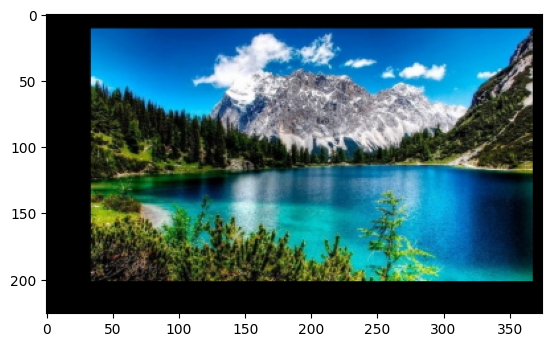

In [4]:
img1 = mpimg.imread('data/image.jpg')
plt.imshow(img1)
print(type(img1))

Look at the shape of this array:

In [5]:
img1.shape

(226, 375, 3)

The image is actually composed of three "layers, or *channels*, for red, green, and blue (RGB) pixel intensities.

Display the same image but this time we'll use another popular Python library for working with images - **cv2**.

numpy.ndarray

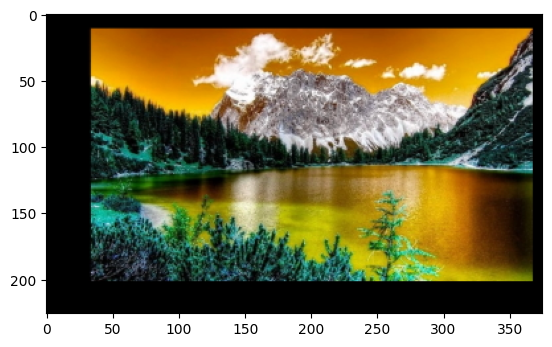

In [6]:
img2 = cv2.imread('data/image.jpg')
plt.imshow(img2)
type(img2)

The trouble is that cv2 loads the array of image data with the channels ordered as blue, green, red (BGR) instead of red, green blue (RGB).

Let's fix that

AxesImage(shape=(226, 375, 3))


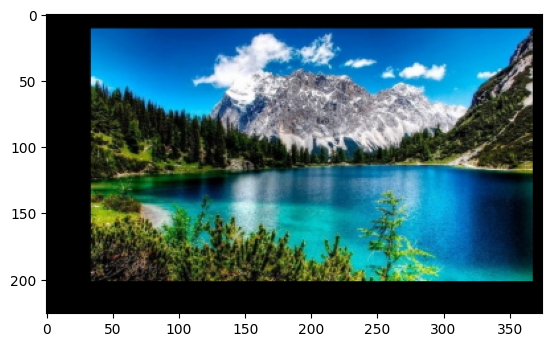

In [7]:
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
print(plt.imshow(img2))

Lastly, one more commonly used library for image processing in Python we should consider - **PIL**:

<class 'PIL.JpegImagePlugin.JpegImageFile'>


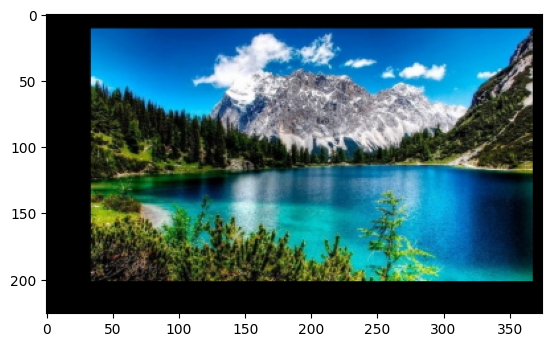

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

img3 = Image.open('data/image.jpg')
plt.imshow(img3)
print(type(img3))

It's easy to convert a PIL JpegImageFile to a numpy array

In [9]:
img3 = np.array(img3)
img3.shape

(226, 375, 3)

Saving a numpy array in an optimized format, should you need to persist images into storage

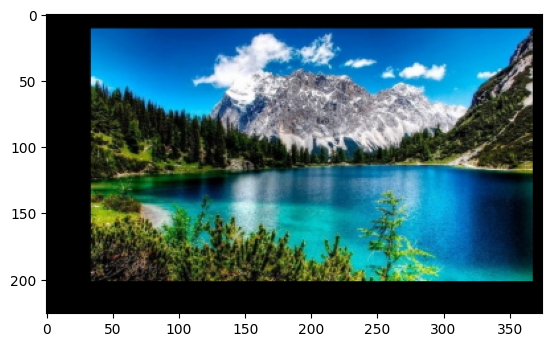

In [10]:
# Save the image
np.save('data/img.npy', img3)

# Load the image
img3 = np.load('data/img.npy')

plt.imshow(img3)

## Resizing an Image <a class="anchor" id="resize"></a>
One of the most common manipulations of an image is to resize it.

Generally, we want to ensure that all of your training images have consistent dimensions.

Original size: 375 x 226
New size: 200 x 200


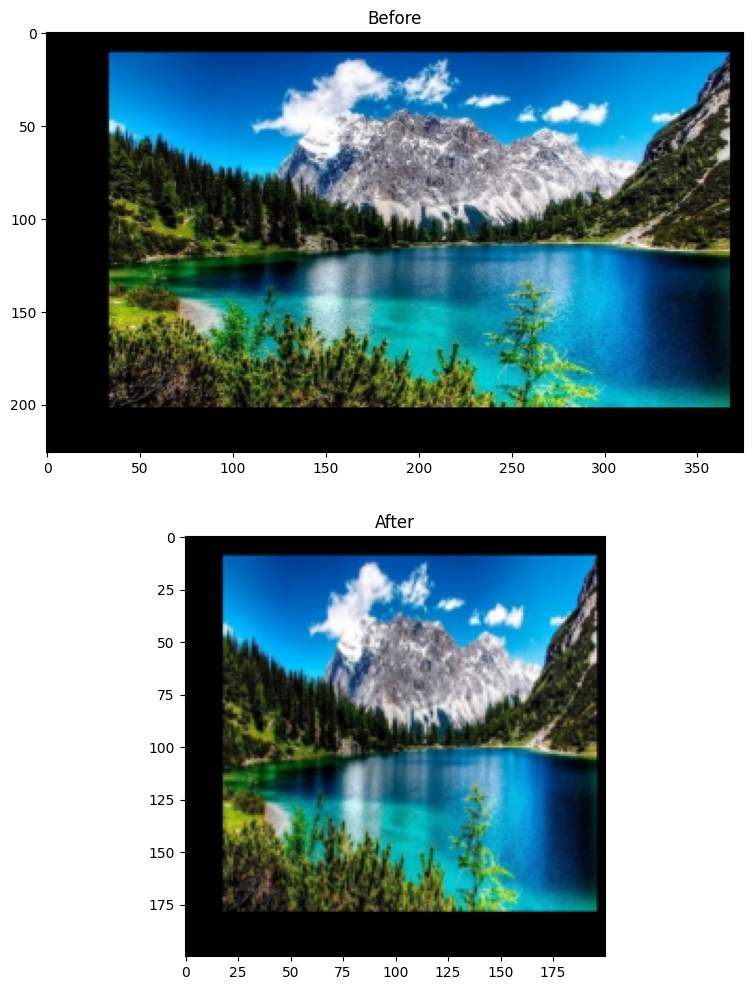

In [11]:
from PIL import Image, ImageOps

# Load the image array into a PIL Image
orig_img = Image.fromarray(img3)

# Get the image size
o_h, o_w = orig_img.size
print('Original size:', o_h, 'x', o_w)

# We'll resize this so it's 200 x 200
target_size = (200,200)
new_img = orig_img.resize(target_size)
n_h, n_w = new_img.size
print('New size:', n_h, 'x', n_w)

# Show the original and resized images
# Create a figure
fig = plt.figure(figsize=(12, 12))

# Subplot for original image
a=fig.add_subplot(2,1,1)
imgplot = plt.imshow(orig_img)
a.set_title('Before')

# Subplot for resized image
a=fig.add_subplot(2,1,2)
imgplot = plt.imshow(new_img)
a.set_title('After')

plt.show()


In [14]:
# Compatibilidad con versiones actuales de Pillow
if not hasattr(Image, 'ANTIALIAS'):
    Image.ANTIALIAS = Image.Resampling.LANCZOS

If we want to resize the image and change its shape without distorting it, we'll need to *scale* the image so that its largest dimension fits our new desired size.

Original size: 375 x 226
Scaled size: 200 x 121
New size: 200 x 200


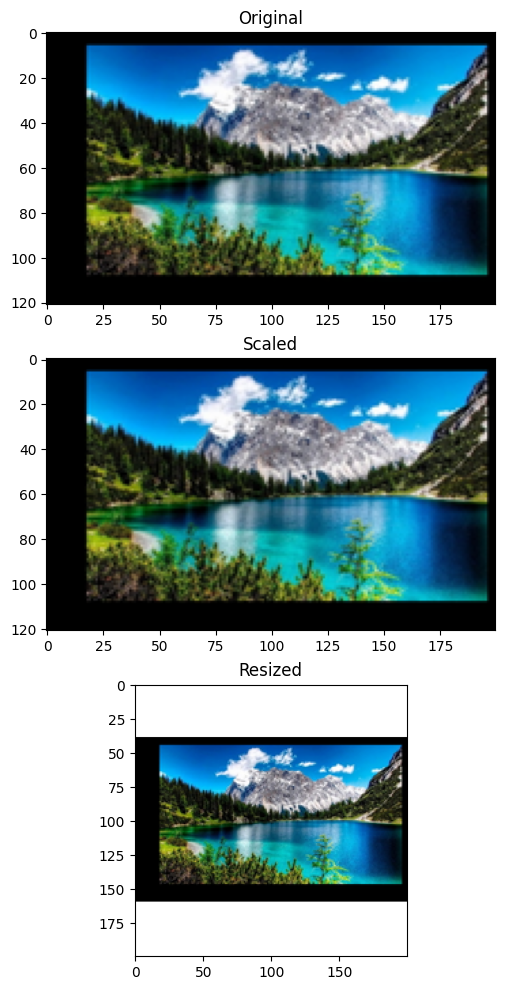

In [15]:
# Get the image size
orig_height, orig_width = orig_img.size
print('Original size:', orig_height, 'x', orig_width)

# We'll resize this so it's 200 x 200
target_size = (200,200)

# Scale the image to the new size using the thumbnail method
scaled_img = orig_img
scaled_img.thumbnail(target_size, Image.ANTIALIAS)
scaled_height, scaled_width = scaled_img.size
print('Scaled size:', scaled_height, 'x', scaled_width)

# Create a new white image of the target size to be the background
new_img = Image.new("RGB", target_size, (255, 255, 255))

# paste the scaled image into the center of the white background image
new_img.paste(scaled_img, (int((target_size[0] - scaled_img.size[0]) / 2), int((target_size[1] - scaled_img.size[1]) / 2)))
new_height, new_width = new_img.size
print('New size:', new_height, 'x', new_width)

# Show the original and resized images
# Create a figure
fig = plt.figure(figsize=(12, 12))

# Subplot for original image
a=fig.add_subplot(3,1,1)
imgplot = plt.imshow(orig_img)
a.set_title('Original')

# Subplot for scaled image
a=fig.add_subplot(3,1,2)
imgplot = plt.imshow(scaled_img)
a.set_title('Scaled')

# Subplot for resized image
a=fig.add_subplot(3,1,3)
imgplot = plt.imshow(new_img)
a.set_title('Resized')

plt.show()

## Negative Images <a class="anchor" id="negative"></a>

In [16]:
orig_img = cv2.imread('data/image.jpg')
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
img_neg = 255 - orig_img

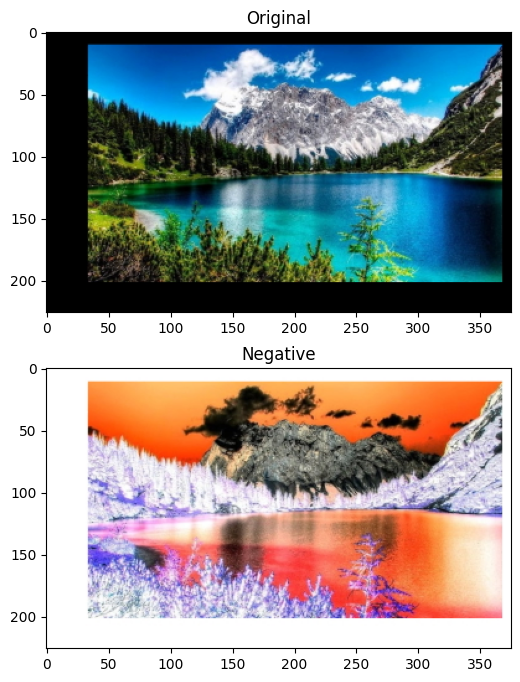

In [17]:
fig = plt.figure(figsize=(8, 8))

# Subplot for original image
a=fig.add_subplot(2,1,1)
imgplot = plt.imshow(orig_img)
a.set_title('Original')

a = fig.add_subplot(2,1,2)
imgplot = plt.imshow(img_neg)
a.set_title('Negative')

plt.show()

## Logarithmic Transformation <a class="anchor" id="log"></a>

$$
S = c * log (1 + r)
$$

where,
- $R$ = input pixel value
- $C$ = scaling constant and
- $S$ = output pixel value

The value of $c$ is chosen such that we get the maximum output value corresponding to the bit size used. So, the formula for calculating $c$  is as follows:

$c = 255 / (log (1 + $ max input pixel value $))$

In [18]:
orig_img = cv2.imread('data/image.jpg')
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

# Apply log transformation method
c = 255 / np.log(1 + np.max(orig_img))
log_img = c * (np.log(orig_img + 1))

# Specify the data type so that
# float value will be converted to int
log_img = np.array(log_img, dtype = np.uint8)

/tmp/ipykernel_1156/418958946.py:5: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(orig_img))
/tmp/ipykernel_1156/418958946.py:5: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(orig_img))
/tmp/ipykernel_1156/418958946.py:6: RuntimeWarning: divide by zero encountered in log
  log_img = c * (np.log(orig_img + 1))
/tmp/ipykernel_1156/418958946.py:6: RuntimeWarning: invalid value encountered in multiply
  log_img = c * (np.log(orig_img + 1))
/tmp/ipykernel_1156/418958946.py:10: RuntimeWarning: invalid value encountered in cast
  log_img = np.array(log_img, dtype = np.uint8)


Log transformation of gives actual information by enhancing the image. If we apply this method in an image having higher pixel values then it will enhance the image more and actual information of the image will be lost.

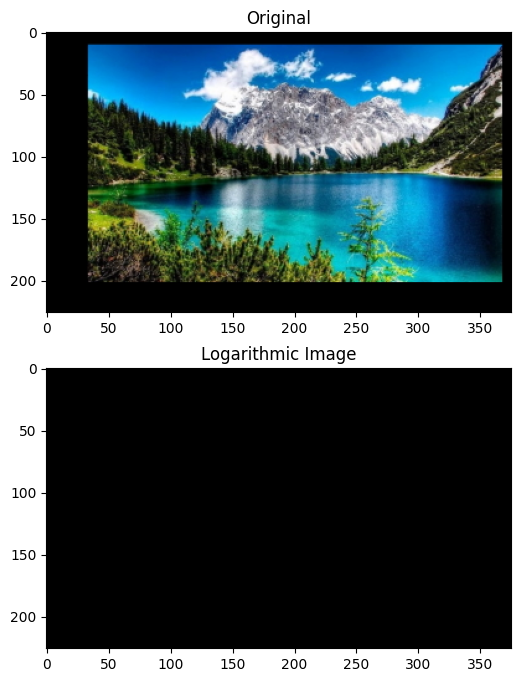

In [19]:
fig = plt.figure(figsize=(8, 8))

# Subplot for original image
a=fig.add_subplot(2,1,1)
imgplot = plt.imshow(orig_img)
a.set_title('Original')

a = fig.add_subplot(2,1,2)
imgplot = plt.imshow(log_img)
a.set_title('Logarithmic Image')

plt.show()

## Image Binarizer (Thresholding) <a class="anchor" id="bin"></a>

Binarize pixels (set pixel values to 0 or 1) according to a threshold.

In [22]:
# Generar el archivo requerido por el notebook
gradient = np.tile(np.arange(256, dtype=np.uint8), (256, 1))
cv2.imwrite('data/linear_gradient.png', gradient)

print("Imagen creada:", 'data/linear_gradient.png')
print("Dimensiones:", gradient.shape)

Imagen creada: data/linear_gradient.png
Dimensiones: (256, 256)


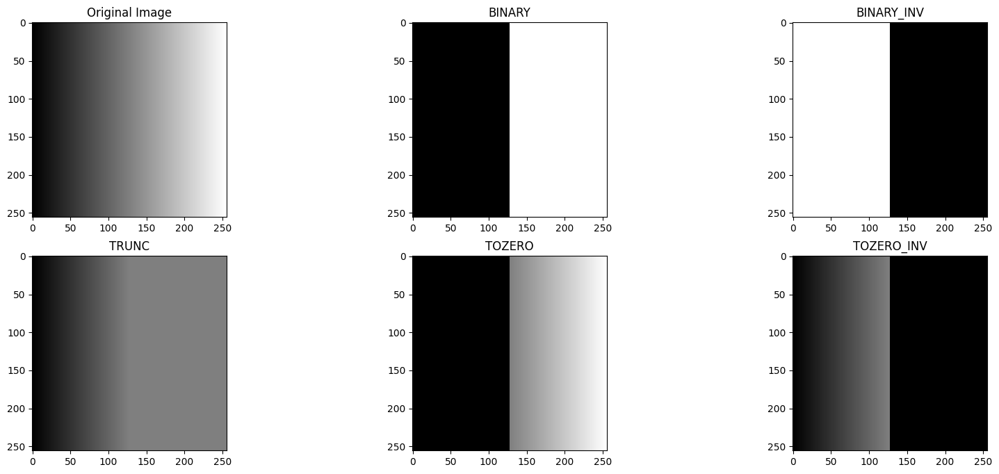

In [23]:
orig_img = cv2.imread('data/linear_gradient.png')
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

ret,thresh1 = cv2.threshold(orig_img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(orig_img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(orig_img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(orig_img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(orig_img,127,255,cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [orig_img, thresh1, thresh2, thresh3, thresh4, thresh5]
n = np.arange(6)

fig = plt.figure(figsize=(20, 8))
for i in n:
  plt.subplot(2,3,i+1), plt.imshow(images[i],'gray')
  plt.title(titles[i])

plt.show()

## Image Quantizer  <a class="anchor" id="quant"></a>

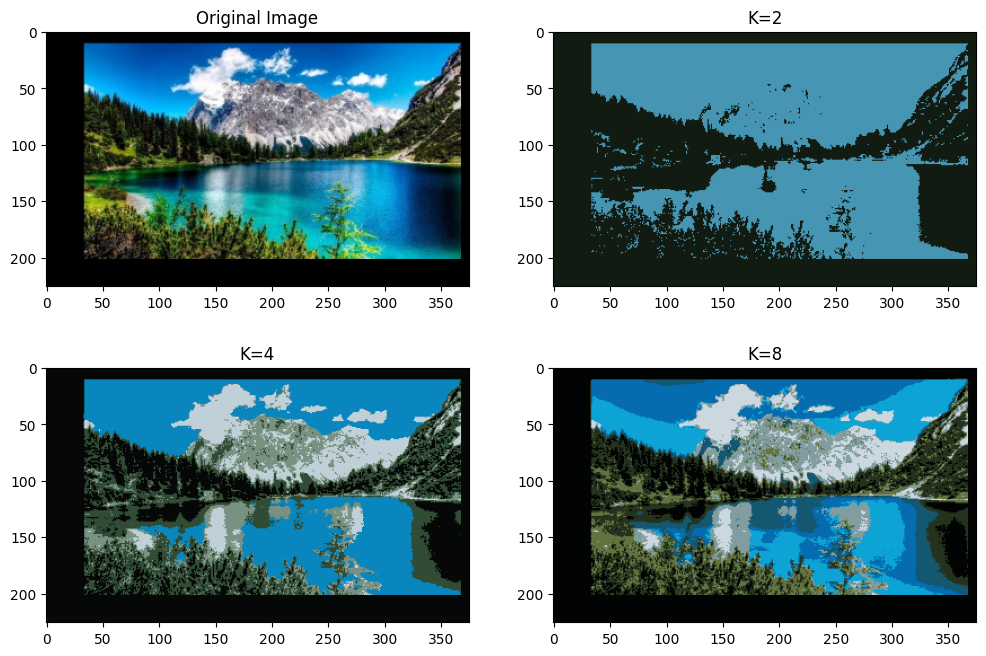

In [25]:
orig_img = cv2.imread('data/image.jpg')

Z = orig_img.reshape((-1,3))

# convert to np.float32
Z = np.float32(Z)

# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
def colorQuant(Z, K, criteria):

   ret,label,center=cv2.kmeans(Z,K,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)

   # Now convert back into uint8, and make original image
   center = np.uint8(center)
   res = center[label.flatten()]
   res2 = res.reshape((orig_img.shape))
   return res2
res1 = colorQuant(Z, 2, criteria)
res2 = colorQuant(Z, 5, criteria)
res3 = colorQuant(Z, 8, criteria)

fig = plt.figure(figsize=(12, 8))

plt.subplot(221),plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')

plt.subplot(222),plt.imshow(cv2.cvtColor(res1, cv2.COLOR_BGR2RGB))
plt.title('K=2')

plt.subplot(223),plt.imshow(cv2.cvtColor(res2, cv2.COLOR_BGR2RGB))
plt.title('K=4')

plt.subplot(224),plt.imshow(cv2.cvtColor(res3, cv2.COLOR_BGR2RGB))
plt.title('K=8')

plt.show()

# Ejercicio 1. Transformaciones píxel a píxel

## Objetivo

Aplicar tres transformaciones píxel a píxel sobre una imagen propia con el propósito de mejorar la visibilidad de una partitura representada dentro de una pintura. Se analizará el efecto de cada transformación sobre la información visual disponible y su utilidad para distinguir los trazos de la partitura respecto del soporte y del resto de la imagen.

Dimensiones: (2268, 4032, 3)
Tipo de datos: uint8


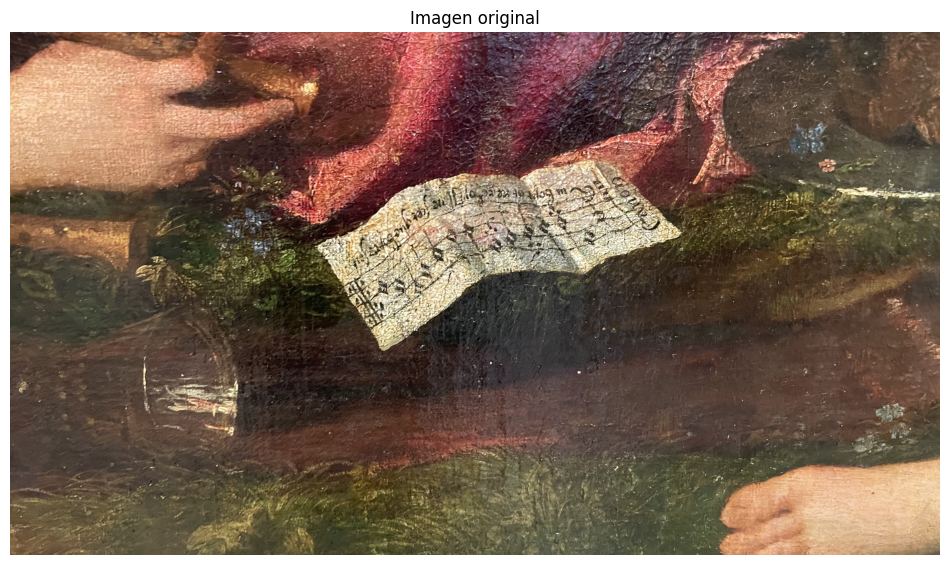

In [27]:
# Carga de la imagen propia
partitura_img = cv2.imread('data/Partitura Museo del Prado.jpg')

# Verificación de la carga
if partitura_img is None:
    raise FileNotFoundError(
        "No se encontró la imagen data/Partitura Museo del Prado.jpg"
    )

# Conversión de BGR a RGB para visualización con Matplotlib
partitura_rgb = cv2.cvtColor(partitura_img, cv2.COLOR_BGR2RGB)

# Verificación de las características de la imagen
print("Dimensiones:", partitura_rgb.shape)
print("Tipo de datos:", partitura_rgb.dtype)

# Visualización de la imagen original
plt.figure(figsize=(12, 8))
plt.imshow(partitura_rgb)
plt.title('Imagen original')
plt.axis('off')
plt.show()
plt.show()

### Imagen seleccionada

Para el desarrollo del ejercicio se utilizó una que tomé el día de ayer en el Museo del Prado, Madrid,   de una pintura que contiene una partitura representada dentro de la escena. El propósito del procesamiento es explorar si distintas operaciones sobre los píxeles permiten mejorar la visibilidad de los trazos correspondientes a la notación musical.

La imagen fue cargada mediante OpenCV y posteriormente convertida del espacio de color BGR a RGB para su correcta visualización con Matplotlib. La verificación de dimensiones y tipo de datos permite confirmar que la imagen fue cargada correctamente antes de realizar cualquier transformación.

Visualmente se observa que la partitura ocupa solamente una región de la imagen completa y está rodeada por elementos de la pintura con diferentes colores, intensidades y texturas. Por esta razón, antes de aplicar las transformaciones píxel a píxel se decidió delimitar una región de interés que concentre el análisis en la zona donde se encuentra la partitura.

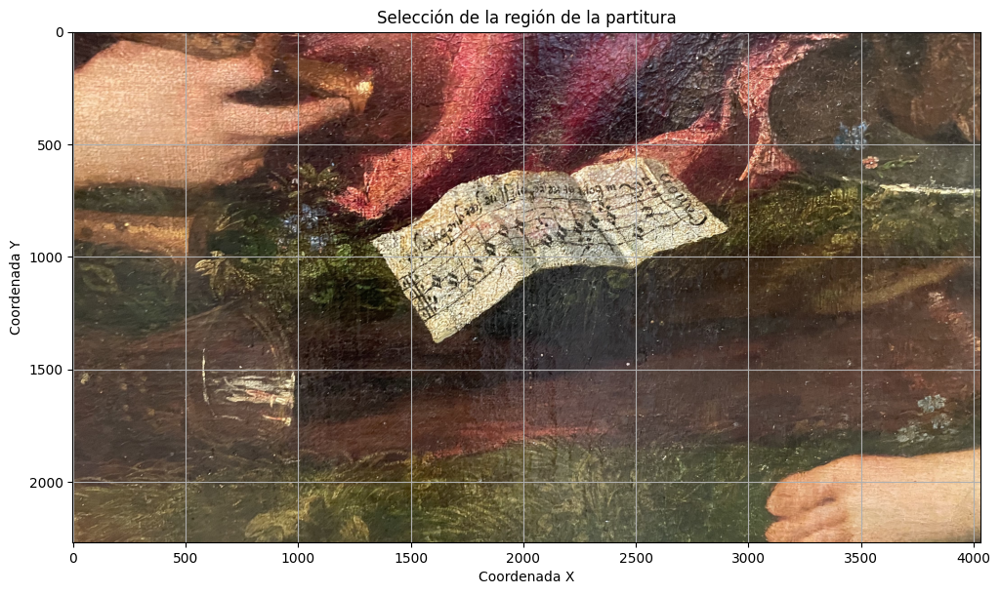

In [28]:
# Visualización para identificar la región de interés
plt.figure(figsize=(12, 8))
plt.imshow(partitura_rgb)
plt.title('Selección de la región de la partitura')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.grid()
plt.show()

### Selección de la región de interés

La visualización de la imagen mediante un sistema de coordenadas permitió localizar la zona que contiene la partitura. A partir de esta inspección se definió una región de interés (ROI) con límites aproximados entre X = 1320 y X = 2900, y entre Y = 550 y Y = 1400.

Esta delimitación se utiliza como una etapa de preparación y no se considera una de las tres transformaciones píxel a píxel solicitadas en el ejercicio. Su finalidad es reducir la influencia de las demás regiones de la pintura y concentrar el procesamiento posterior en la información visual asociada con la partitura.

Dimensiones de la imagen original: (2268, 4032, 3)
Dimensiones de la región de interés: (850, 1580, 3)


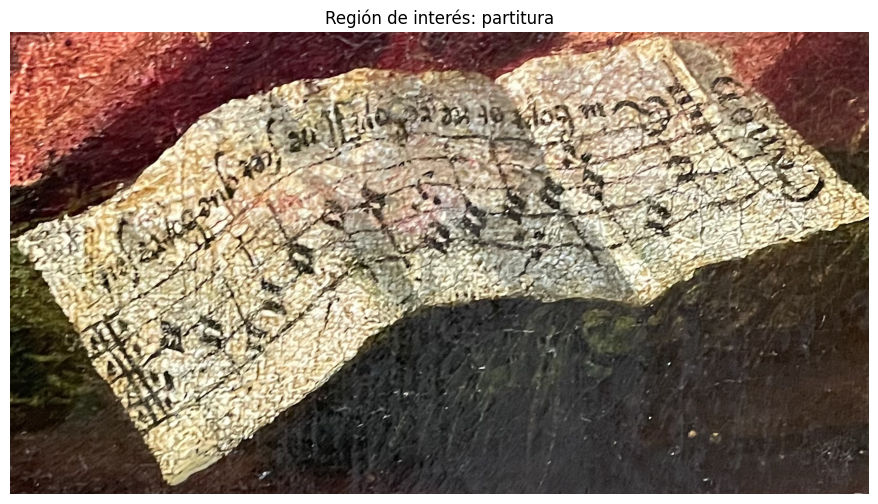

In [29]:
# Definición de la región de interés (ROI)
x1, x2 = 1320, 2900
y1, y2 = 550, 1400

# Recorte de la región que contiene la partitura
partitura_roi = partitura_rgb[y1:y2, x1:x2]

# Verificación
print("Dimensiones de la imagen original:", partitura_rgb.shape)
print("Dimensiones de la región de interés:", partitura_roi.shape)

# Visualización
plt.figure(figsize=(12, 6))
plt.imshow(partitura_roi)
plt.title('Región de interés: partitura')
plt.axis('off')
plt.show()

### Resultado de la extracción de la región de interés

La imagen original presenta dimensiones de 2268 × 4032 píxeles y tres canales de color. Después del recorte, la región de interés presenta dimensiones de 850 × 1580 píxeles y conserva los tres canales.

El resultado permite concentrar el análisis en la zona donde se encuentra la partitura. Visualmente, la región seleccionada conserva la notación musical visible y el soporte sobre el que está representada, aunque también permanecen pequeñas zonas correspondientes al fondo de la pintura debido a la forma irregular e inclinada de la partitura.

Se decidió conservar este recorte sin realizar una segmentación adicional en esta etapa, ya que el objetivo siguiente es evaluar el efecto de las transformaciones píxel a píxel sobre la información visual disponible. De esta manera será posible comparar posteriormente si dichas transformaciones facilitan la diferenciación entre los trazos oscuros de la notación, el soporte claro y las regiones circundantes.

Dimensiones del ROI en color: (850, 1580, 3)
Dimensiones en escala de grises: (850, 1580)
Tipo de datos: uint8
Intensidad mínima: 0
Intensidad máxima: 255


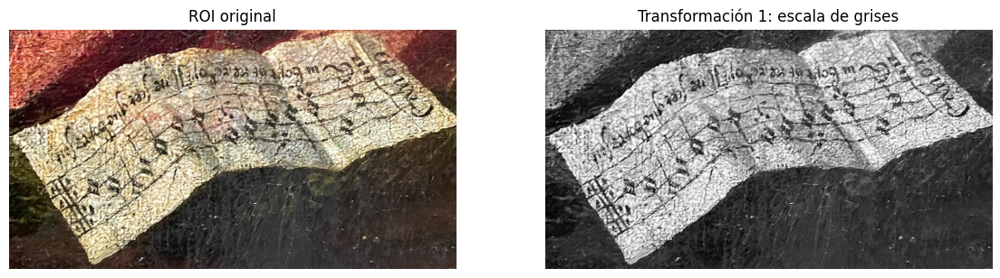

In [30]:
# Transformación 1: conversión a escala de grises
partitura_gray = cv2.cvtColor(partitura_roi, cv2.COLOR_RGB2GRAY)

# Verificación
print("Dimensiones del ROI en color:", partitura_roi.shape)
print("Dimensiones en escala de grises:", partitura_gray.shape)
print("Tipo de datos:", partitura_gray.dtype)
print("Intensidad mínima:", partitura_gray.min())
print("Intensidad máxima:", partitura_gray.max())

# Comparación visual
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(partitura_roi)
plt.title('ROI original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(partitura_gray, cmap='gray')
plt.title('Transformación 1: escala de grises')
plt.axis('off')

plt.show()

### Análisis de la Transformación 1: escala de grises

La primera transformación consistió en convertir la región de interés de una imagen RGB a una representación en escala de grises. Como resultado, las dimensiones cambiaron de (850, 1580, 3) a (850, 1580), debido a que los tres canales de color fueron sustituidos por un único canal de intensidad. La imagen resultante mantiene un tipo de datos `uint8` y presenta valores de intensidad comprendidos entre 0 y 255.

La comparación visual muestra que la eliminación de la información cromática conserva las principales estructuras presentes en la región de interés. Los trazos oscuros asociados con la notación musical continúan siendo visibles sobre las regiones más claras del soporte. Al mismo tiempo, también permanecen variaciones de intensidad producidas por la textura y los elementos propios de la pintura, por lo que la conversión a escala de grises no permite por sí sola aislar la notación musical.

Esta transformación resulta útil como etapa inicial del procesamiento porque reduce la representación de tres canales a uno y permite que las operaciones posteriores se concentren en las diferencias de intensidad. A partir de este resultado se evaluará una segunda transformación orientada a incrementar la separación visual entre los trazos oscuros y las zonas claras de la partitura.

Dimensiones: (850, 1580)
Tipo de datos: uint8
Intensidad mínima: 0
Intensidad máxima: 255


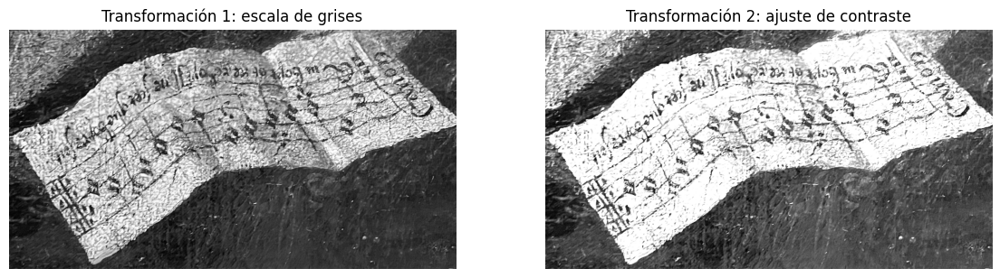

In [31]:
# Transformación 2: ajuste lineal de contraste
alpha = 1.5
beta = 0

partitura_contrast = cv2.convertScaleAbs(
    partitura_gray,
    alpha=alpha,
    beta=beta
)

# Verificación
print("Dimensiones:", partitura_contrast.shape)
print("Tipo de datos:", partitura_contrast.dtype)
print("Intensidad mínima:", partitura_contrast.min())
print("Intensidad máxima:", partitura_contrast.max())

# Comparación visual
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(partitura_gray, cmap='gray')
plt.title('Transformación 1: escala de grises')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(partitura_contrast, cmap='gray')
plt.title('Transformación 2: ajuste de contraste')
plt.axis('off')

plt.show()

### Análisis de la Transformación 2: ajuste lineal de contraste

La segunda transformación aplicó un ajuste lineal de contraste sobre la imagen en escala de grises, utilizando un factor `alpha = 1.5` y un desplazamiento `beta = 0`. La imagen resultante conserva dimensiones de 850 × 1580 píxeles, tipo de datos `uint8` y un intervalo de intensidades entre 0 y 255.

La comparación visual muestra un incremento evidente en la luminosidad de las regiones claras del soporte y una mayor separación entre algunas zonas claras y oscuras. Sin embargo, para el objetivo específico de distinguir la notación musical, el resultado presenta una mejora limitada. Los trazos de la partitura permanecen visibles, pero el aumento de contraste también resalta irregularidades, texturas y otros trazos presentes en la pintura.

Por lo tanto, incrementar globalmente el contraste no permite aislar por sí solo la información correspondiente a la notación musical. Este resultado evidencia que una transformación global puede modificar simultáneamente tanto la información de interés como otros elementos de la imagen. Se requiere una transformación adicional que permita separar de manera más explícita los píxeles según sus niveles de intensidad.

Umbral calculado por Otsu: 123.0
Dimensiones: (850, 1580)
Tipo de datos: uint8
Valores presentes: [  0 255]


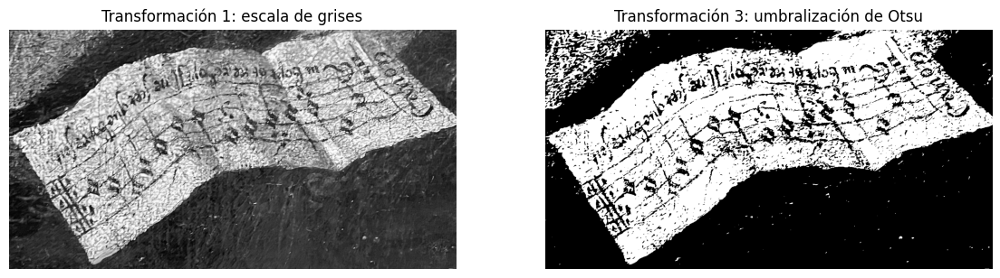

In [32]:
# Transformación 3: umbralización automática mediante el método de Otsu
umbral_otsu, partitura_binary = cv2.threshold(
    partitura_gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Verificación
print("Umbral calculado por Otsu:", umbral_otsu)
print("Dimensiones:", partitura_binary.shape)
print("Tipo de datos:", partitura_binary.dtype)
print("Valores presentes:", np.unique(partitura_binary))

# Comparación visual
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(partitura_gray, cmap='gray')
plt.title('Transformación 1: escala de grises')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(partitura_binary, cmap='gray')
plt.title('Transformación 3: umbralización de Otsu')
plt.axis('off')

plt.show()

### Análisis de la Transformación 3: umbralización de Otsu

La tercera transformación consistió en una umbralización binaria utilizando el método de Otsu. El algoritmo determinó automáticamente un umbral de intensidad de 123. Como resultado, la imagen conserva dimensiones de 850 × 1580 píxeles y tipo de datos `uint8`, pero sus valores quedan reducidos exclusivamente a 0 y 255, correspondientes a las dos clases de la imagen binaria.

Visualmente, la transformación produce una separación más marcada entre regiones claras y oscuras. Parte de los trazos correspondientes a la notación musical permanece visible; sin embargo, la segmentación también clasifica como píxeles oscuros otras estructuras presentes en la pintura, incluyendo regiones del fondo, sombras y textura del soporte.

Por lo tanto, aunque la umbralización permite simplificar considerablemente la representación de la imagen, en este caso no consigue aislar de manera exclusiva la notación musical. El resultado indica que las diferencias de intensidad entre la información de interés y el resto de los elementos pictóricos no son suficientes para realizar una separación completa mediante un único umbral global.

Dimensiones: (850, 1580)
Tipo de datos: uint8
Intensidad mínima: 0
Intensidad máxima: 255


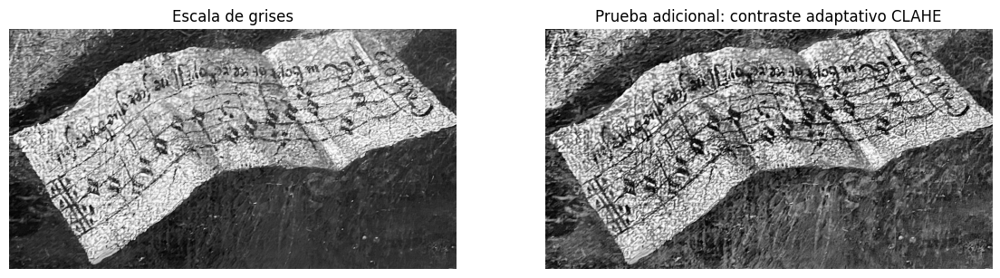

In [34]:
# Prueba adicional: mejora de contraste local mediante CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

partitura_clahe = clahe.apply(partitura_gray)

# Verificación
print("Dimensiones:", partitura_clahe.shape)
print("Tipo de datos:", partitura_clahe.dtype)
print("Intensidad mínima:", partitura_clahe.min())
print("Intensidad máxima:", partitura_clahe.max())

# Comparación visual
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(partitura_gray, cmap='gray')
plt.title('Escala de grises')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(partitura_clahe, cmap='gray')
plt.title('Prueba adicional: contraste adaptativo CLAHE')
plt.axis('off')

plt.show()

### Análisis de la prueba adicional: contraste adaptativo CLAHE

Como prueba adicional se aplicó CLAHE (Contrast Limited Adaptive Histogram Equalization) sobre la imagen en escala de grises. La imagen resultante conserva dimensiones de 850 × 1580 píxeles, tipo de datos `uint8` y un intervalo de intensidades entre 0 y 255.

En comparación con la escala de grises original, el resultado muestra un incremento del contraste local. Algunos trazos de la notación musical y líneas presentes sobre el soporte adquieren mayor definición visual. Sin embargo, el procedimiento también incrementa la visibilidad de la textura propia de la pintura y de otras irregularidades que no corresponden exclusivamente a la información musical.

El resultado muestra una diferencia respecto del ajuste lineal de contraste aplicado previamente. Mientras aquel modificó globalmente las intensidades y produjo regiones claras con mayor luminosidad, CLAHE permite resaltar diferencias locales. No obstante, el aumento de detalle afecta tanto a los trazos de interés como a la textura pictórica, por lo que tampoco permite aislar por sí solo la partitura.

Esta prueba evidencia que aumentar el contraste no necesariamente implica una mejor separación de la información de interés cuando los trazos y la textura presentan intensidades similares.

Dimensiones: (850, 1580)
Tipo de datos: uint8
Valores presentes: [  0 255]


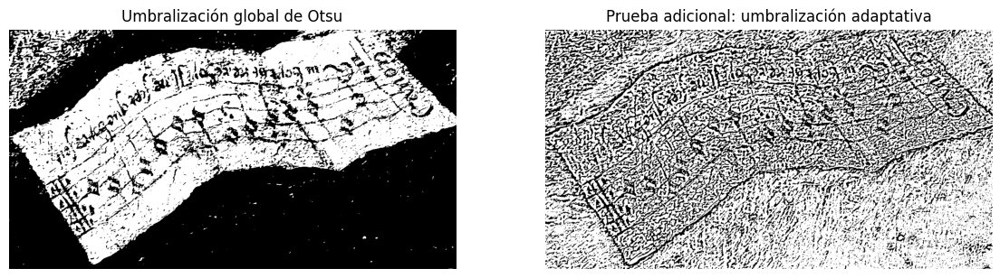

In [35]:
# Prueba adicional: umbralización adaptativa
partitura_adaptive = cv2.adaptiveThreshold(
    partitura_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    7
)

# Verificación
print("Dimensiones:", partitura_adaptive.shape)
print("Tipo de datos:", partitura_adaptive.dtype)
print("Valores presentes:", np.unique(partitura_adaptive))

# Comparación visual
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(partitura_binary, cmap='gray')
plt.title('Umbralización global de Otsu')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(partitura_adaptive, cmap='gray')
plt.title('Prueba adicional: umbralización adaptativa')
plt.axis('off')

plt.show()

### Análisis de la prueba adicional: umbralización adaptativa

Como prueba adicional se aplicó una umbralización adaptativa para evaluar si el cálculo local del umbral permitía distinguir mejor la notación musical frente al resultado obtenido mediante el umbral global de Otsu. La imagen resultante conserva dimensiones de 850 × 1580 píxeles, tipo de datos `uint8` y únicamente contiene valores de intensidad 0 y 255.

La comparación muestra que la umbralización adaptativa conserva una mayor cantidad de variaciones locales que la umbralización global. Sin embargo, en esta imagen dichas variaciones no corresponden exclusivamente a los trazos de la partitura. La textura pictórica, las irregularidades del soporte y otras estructuras presentes en la región de interés también son representadas mediante numerosos trazos oscuros.

En consecuencia, el incremento del detalle local no produce una mejor separación visual de la notación musical. Para esta imagen, la umbralización global de Otsu genera una representación más simplificada, mientras que la umbralización adaptativa conserva una cantidad considerable de información no relacionada exclusivamente con la partitura.

Este resultado refuerza la observación obtenida en las pruebas anteriores: la dificultad para aislar la notación no depende únicamente del nivel de contraste o de la variación de iluminación, sino de la coexistencia de trazos, texturas y estructuras pictóricas con intensidades similares.

## Comparación y discusión de las transformaciones aplicadas

Las transformaciones de intensidad permiten modificar los valores de los píxeles con el propósito de resaltar características relevantes de una imagen. En este ejercicio se analizaron diferentes alternativas sobre una fotografía de una pintura que contiene una partitura, utilizando como objetivo práctico mejorar la visibilidad de los trazos correspondientes a la notación musical.

La conversión a escala de grises permitió eliminar la información cromática y representar la región de interés mediante un único canal de intensidad. Esta transformación conservó las estructuras principales de la partitura y simplificó el procesamiento posterior, aunque no eliminó las texturas y variaciones de intensidad presentes en la pintura.

Posteriormente, el ajuste lineal de contraste con un factor `alpha = 1.5` incrementó globalmente las diferencias de intensidad. Sin embargo, el resultado mostró que aumentar el contraste no necesariamente facilita la identificación de la información de interés, ya que también se modificaron las texturas y otras estructuras presentes en la imagen.

La umbralización mediante el método de Otsu produjo una imagen binaria y calculó automáticamente un umbral de 123. Esta transformación generó una separación más marcada entre regiones claras y oscuras, pero los píxeles oscuros no correspondieron exclusivamente a la notación musical. Las sombras, el fondo y otras estructuras pictóricas también fueron clasificadas dentro de la misma categoría.

Como pruebas adicionales se utilizaron CLAHE y umbralización adaptativa. CLAHE produjo un incremento del contraste local y permitió observar con mayor definición algunos trazos, aunque simultáneamente aumentó la visibilidad de la textura pictórica. La umbralización adaptativa, por su parte, conservó una gran cantidad de variaciones locales y produjo numerosos trazos asociados con la textura, por lo que no mejoró la separación de la notación.

En conjunto, los resultados muestran que las transformaciones evaluadas modifican de manera diferente la representación de la imagen, pero ninguna permite recuperar de forma aislada la partitura. La principal dificultad observada es que los trazos musicales, la textura del soporte, las sombras y otros elementos pictóricos presentan variaciones de intensidad que se superponen. Por esta razón, incrementar el contraste o aplicar una separación basada exclusivamente en intensidad también resalta información que no pertenece a la notación musical.

El ejercicio permite comprobar experimentalmente que la utilidad de una transformación depende de las características de la imagen y del objetivo del procesamiento. En este caso, la escala de grises resultó útil como representación inicial; el contraste lineal y CLAHE modificaron la visibilidad de los detalles; y las técnicas de umbralización mostraron las limitaciones de separar mediante intensidad una estructura integrada en una superficie pictórica compleja.

### Fundamentación bibliográfica

Gonzalez y Woods presentan las transformaciones de intensidad como operaciones fundamentales del procesamiento digital de imágenes para modificar la representación de los niveles de intensidad y facilitar tareas posteriores de análisis. Estas operaciones permiten estudiar cómo diferentes funciones de transformación afectan la información visual contenida en una imagen.

La documentación oficial de OpenCV establece que la umbralización permite clasificar los píxeles mediante sus valores de intensidad. En la umbralización global se utiliza un mismo valor para toda la imagen, mientras que el método de Otsu determina automáticamente un umbral a partir de la distribución de intensidades. OpenCV también señala que la umbralización adaptativa calcula diferentes umbrales en regiones locales, lo que puede resultar útil cuando existen variaciones de iluminación.

Por otra parte, la ecualización de histograma busca mejorar el contraste mediante una redistribución de los niveles de intensidad. CLAHE extiende este enfoque realizando el procesamiento sobre regiones locales y limitando la amplificación del contraste. Esta característica resulta relevante para imágenes en las que las condiciones de intensidad no son uniformes.

Los resultados obtenidos en este ejercicio muestran también las limitaciones de estas técnicas. Aunque las transformaciones modificaron el contraste y la separación de intensidades, la textura de la pintura y los trazos musicales contienen características visuales superpuestas, por lo que el aumento de contraste o la binarización no producen necesariamente una separación exclusiva de la información musical.

### Referencias

1. Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.). Pearson.
2. OpenCV. *Image Thresholding*. OpenCV-Python Tutorials.
3. OpenCV. *Histograms - 2: Histogram Equalization*. OpenCV-Python Tutorials.

https://docs.opencv.org/4.12.0/d7/d4d/tutorial_py_thresholding.html?utm_source=chatgpt.com

https://docs.opencv.org/4.12.0/d5/daf/tutorial_py_histogram_equalization.html?utm_source=chatgpt.com

# Ejercicio 2. Negativo de una imagen

## Aplicación investigada

El negativo es una transformación de intensidad que invierte los niveles de una imagen. Para una imagen de 8 bits, cuyos valores se encuentran entre 0 y 255, la transformación puede expresarse como:

\[
s = 255-r
\]

donde \(r\) representa la intensidad original del píxel y \(s\) la intensidad resultante.

Una aplicación de esta transformación se encuentra en la visualización de imágenes radiográficas. Gonzalez y Woods señalan que los negativos de imágenes digitales pueden resultar útiles para resaltar detalles claros contenidos en regiones predominantemente oscuras. La inversión modifica la representación visual de las intensidades sin alterar la posición espacial de las estructuras presentes en la imagen.

En este ejercicio se realiza una demostración de la transformación negativa utilizando la región de interés de la imagen empleada anteriormente. El propósito de la demostración es observar directamente cómo se invierten los niveles de intensidad, sin asumir que el negativo necesariamente producirá una mejor representación de la partitura.

**Referencia:** Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.). Pearson.

Dimensiones: (850, 1580)
Tipo de datos: uint8
Intensidad mínima: 0
Intensidad máxima: 255


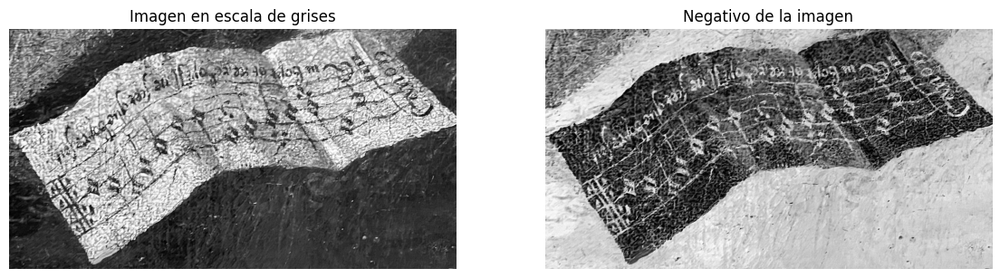

In [36]:
# Ejercicio 2: negativo de la imagen
partitura_negative = 255 - partitura_gray

# Verificación
print("Dimensiones:", partitura_negative.shape)
print("Tipo de datos:", partitura_negative.dtype)
print("Intensidad mínima:", partitura_negative.min())
print("Intensidad máxima:", partitura_negative.max())

# Comparación visual
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(partitura_gray, cmap='gray')
plt.title('Imagen en escala de grises')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(partitura_negative, cmap='gray')
plt.title('Negativo de la imagen')
plt.axis('off')

plt.show()

### Análisis del resultado

La transformación negativa se aplicó sobre la región de interés previamente convertida a escala de grises. El resultado conserva las dimensiones de 850 × 1580 píxeles y el tipo de datos `uint8`. Asimismo, se mantiene el intervalo completo de intensidades entre 0 y 255.

La comparación visual permite observar directamente la inversión de los niveles de intensidad. Las regiones claras del soporte de la partitura se convierten en regiones oscuras, mientras que los trazos originalmente oscuros adquieren intensidades claras. La estructura espacial de los elementos de la imagen permanece sin cambios, debido a que la operación modifica individualmente el valor de intensidad de cada píxel mediante la relación \(s = 255-r\).

En esta imagen, el negativo no permite aislar la notación musical ni produce una recuperación adicional de información respecto de la imagen en escala de grises. Sin embargo, la demostración permite comprobar cómo una inversión de intensidades modifica la percepción de estructuras claras y oscuras sin modificar su posición.

Este comportamiento permite comprender la utilidad de la transformación negativa en aplicaciones donde resulta conveniente invertir la representación visual de las intensidades. En particular, Gonzalez y Woods describen su utilidad para visualizar detalles claros contenidos en regiones predominantemente oscuras, incluyendo aplicaciones sobre imágenes digitales de tipo radiográfico.

### Relación entre la aplicación investigada y la demostración

La aplicación radiográfica investigada y la demostración realizada comparten el mismo principio matemático de inversión de intensidades. No obstante, la imagen utilizada en este ejercicio no corresponde a una imagen médica y, por lo tanto, el resultado no pretende demostrar una mejora diagnóstica. Su finalidad es comprobar experimentalmente el comportamiento de la transformación negativa y observar cómo las estructuras oscuras pasan a representarse mediante intensidades claras y viceversa.

En el caso particular de la pintura analizada, la transformación modifica claramente la representación visual de la partitura, pero no permite aislarla ni recuperar información adicional. Esto evidencia que la utilidad de una transformación depende tanto de sus propiedades matemáticas como de las características y del propósito de la imagen sobre la que se aplica.

# Ejercicio 3. Corrección gamma

## Aplicación investigada

La corrección gamma es una transformación no lineal de intensidad que puede expresarse mediante una función de potencia:

\[
s = c r^{\gamma}
\]

donde \(r\) representa la intensidad de entrada normalizada, \(s\) la intensidad de salida, \(c\) una constante y \(\gamma\) el parámetro que controla la transformación.

Una aplicación de esta transformación se encuentra en la corrección y visualización de imágenes cuando se requiere modificar la relación entre los niveles de intensidad. A diferencia de una transformación lineal, la función gamma permite modificar de manera diferente las distintas regiones del intervalo de intensidades.

Gonzalez y Woods presentan las transformaciones de potencia como una herramienta fundamental del procesamiento digital de imágenes y describen su relación con la corrección gamma utilizada en dispositivos de adquisición, impresión y visualización.

En esta demostración se aplicarán dos valores de gamma sobre la región de interés utilizada en los ejercicios anteriores. El propósito es comparar experimentalmente su efecto sobre la distribución visual de intensidades y determinar, a partir de los resultados obtenidos, si alguno facilita la observación de los trazos de la partitura.

**Referencia:** Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.). Pearson.

Imagen original: (850, 1580) uint8
Gamma 0.5: (850, 1580) uint8
Gamma 2.0: (850, 1580) uint8
Rango gamma 0.5: 0 255
Rango gamma 2.0: 0 255


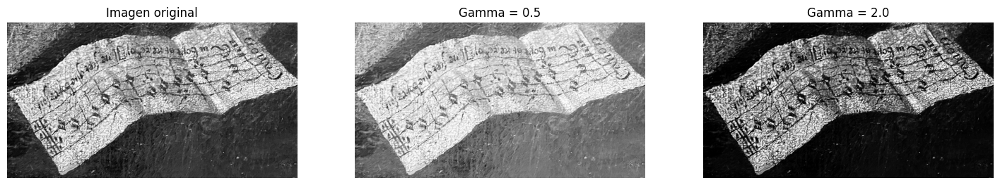

In [37]:
# Ejercicio 3: corrección gamma

# Normalización de intensidades al intervalo [0, 1]
partitura_normalized = partitura_gray / 255.0

# Aplicación de dos valores de gamma
gamma_05 = 0.5
gamma_20 = 2.0

partitura_gamma_05 = np.power(
    partitura_normalized,
    gamma_05
)

partitura_gamma_20 = np.power(
    partitura_normalized,
    gamma_20
)

# Conversión al intervalo [0, 255]
partitura_gamma_05 = np.uint8(
    np.clip(partitura_gamma_05 * 255, 0, 255)
)

partitura_gamma_20 = np.uint8(
    np.clip(partitura_gamma_20 * 255, 0, 255)
)

# Verificación
print("Imagen original:", partitura_gray.shape, partitura_gray.dtype)
print("Gamma 0.5:", partitura_gamma_05.shape, partitura_gamma_05.dtype)
print("Gamma 2.0:", partitura_gamma_20.shape, partitura_gamma_20.dtype)

print("Rango gamma 0.5:",
      partitura_gamma_05.min(),
      partitura_gamma_05.max())

print("Rango gamma 2.0:",
      partitura_gamma_20.min(),
      partitura_gamma_20.max())

# Comparación visual
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(partitura_gray, cmap='gray')
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(partitura_gamma_05, cmap='gray')
plt.title('Gamma = 0.5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(partitura_gamma_20, cmap='gray')
plt.title('Gamma = 2.0')
plt.axis('off')

plt.show()

### Análisis del resultado

La corrección gamma se aplicó utilizando dos valores, \(\gamma = 0.5\) y \(\gamma = 2.0\), con el propósito de observar el efecto de una transformación no lineal sobre los niveles de intensidad. En ambos casos, las imágenes resultantes conservaron dimensiones de 850 × 1580 píxeles, tipo de datos `uint8` y un intervalo de intensidades entre 0 y 255.

La transformación con \(\gamma = 0.5\) produjo una imagen visualmente más clara. Las regiones correspondientes al soporte de la partitura aumentaron su luminosidad y también se modificó la apariencia de los trazos y de la textura presentes en la pintura. En este caso, el incremento de luminosidad no produjo una separación más clara de la notación musical.

Por el contrario, con \(\gamma = 2.0\) la imagen presentó un desplazamiento visual hacia intensidades más oscuras. Algunos trazos adquirieron mayor presencia visual, pero simultáneamente se intensificaron las sombras y otras estructuras de la pintura. Por esta razón, tampoco se obtuvo una separación exclusiva de la información musical.

La comparación evidencia que la corrección gamma permite controlar de manera no lineal la representación de las intensidades. A diferencia del ajuste lineal de contraste evaluado anteriormente, los niveles de intensidad no se modifican todos en la misma proporción. Los resultados obtenidos muestran además que una modificación perceptualmente más intensa no implica necesariamente una mejor extracción de la información de interés.

Para la imagen analizada, los dos valores de gamma modificaron claramente su apariencia, pero ninguno permitió aislar la partitura. Esto confirma la importancia de seleccionar los parámetros de transformación de acuerdo con las características de la imagen y con el objetivo específico del procesamiento.

### Relación entre la aplicación investigada y la demostración

La corrección gamma tiene una aplicación directa en sistemas de adquisición y visualización de imágenes, debido a que permite compensar o modificar relaciones no lineales entre los valores de intensidad y su representación visual. Las transformaciones de potencia permiten controlar de manera diferenciada las regiones del intervalo de intensidades, por lo que su efecto es distinto al obtenido mediante un ajuste lineal de brillo o contraste.

La demostración realizada permite observar experimentalmente este comportamiento. Al utilizar \(\gamma = 0.5\), la representación de la imagen se desplazó hacia intensidades más claras, mientras que con \(\gamma = 2.0\) se produjo una representación visualmente más oscura. En ambos casos se conservaron las dimensiones, el tipo de datos y el intervalo final de 0 a 255.

En el caso particular de la pintura analizada, modificar la distribución de intensidades no fue suficiente para aislar la notación musical. Este resultado no contradice la utilidad de la corrección gamma, sino que muestra que su propósito principal en esta demostración es modificar la representación de las intensidades y no realizar una segmentación de los objetos presentes en la imagen.

**Referencia:** Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.). Pearson.

# Ejercicio 4. Sustracción de imágenes

## Aplicación investigada

La sustracción de imágenes permite identificar diferencias entre dos imágenes comparables. Si dos imágenes representan la misma escena y se encuentran espacialmente alineadas, la diferencia entre los valores correspondientes de sus píxeles permite resaltar las regiones que han experimentado algún cambio.

Una aplicación de este principio es la detección de cambios entre imágenes adquiridas en diferentes momentos. El procedimiento puede emplearse para localizar regiones modificadas mientras las zonas que permanecen sin cambios presentan diferencias reducidas.

Para demostrar el funcionamiento de esta operación se utilizará la región de interés de la partitura en escala de grises. A partir de ella se generará programáticamente una segunda imagen con una modificación localizada y conocida. Posteriormente se calculará la diferencia absoluta entre ambas imágenes. Este procedimiento constituye una demostración controlada del principio de sustracción y no pretende representar un cambio real ocurrido en la pintura.

**Referencia:** Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.). Pearson.

Imagen original: (850, 1580) uint8
Imagen modificada: (850, 1580) uint8
Imagen diferencia: (850, 1580) uint8
Diferencia mínima: 0
Diferencia máxima: 253
Píxeles con diferencia: 15000


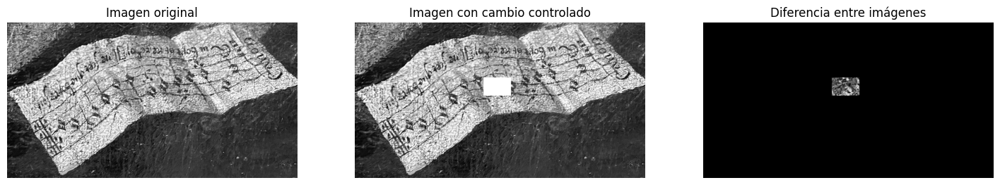

In [38]:
# Ejercicio 4: demostración de sustracción de imágenes

# Copia de la imagen original
partitura_modified = partitura_gray.copy()

# Introducción de un cambio controlado en una región
partitura_modified[300:400, 700:850] = 255

# Diferencia absoluta entre las dos imágenes
partitura_difference = cv2.absdiff(
    partitura_gray,
    partitura_modified
)

# Verificación
print("Imagen original:", partitura_gray.shape, partitura_gray.dtype)
print("Imagen modificada:", partitura_modified.shape, partitura_modified.dtype)
print("Imagen diferencia:", partitura_difference.shape, partitura_difference.dtype)
print("Diferencia mínima:", partitura_difference.min())
print("Diferencia máxima:", partitura_difference.max())
print("Píxeles con diferencia:",
      np.count_nonzero(partitura_difference))

# Visualización
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(partitura_gray, cmap='gray')
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(partitura_modified, cmap='gray')
plt.title('Imagen con cambio controlado')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(partitura_difference, cmap='gray')
plt.title('Diferencia entre imágenes')
plt.axis('off')

plt.show()

### Análisis del resultado

La demostración de sustracción se realizó a partir de dos imágenes con las mismas dimensiones de 850 × 1580 píxeles y tipo de datos `uint8`. La segunda imagen se obtuvo mediante una copia de la imagen original, sobre la cual se introdujo de manera controlada una región rectangular de 100 × 150 píxeles.

La diferencia absoluta entre ambas imágenes produjo valores comprendidos entre 0 y 253. Las regiones que no fueron modificadas presentan una diferencia igual a cero y, por esta razón, aparecen negras en la imagen resultante. En contraste, la región modificada presenta valores distintos de cero y puede localizarse claramente en la imagen de diferencias.

La verificación cuantitativa identificó 15,000 píxeles con diferencia. Este resultado coincide exactamente con el área de la región modificada:

\[
100 \times 150 = 15,000 \text{ píxeles}
\]

Por lo tanto, la operación permitió detectar todos los píxeles incluidos en el cambio controlado. El valor máximo de diferencia fue 253 y no necesariamente 255, debido a que la magnitud de la diferencia depende de la intensidad que cada píxel tenía originalmente antes de ser sustituido por el valor 255.

La demostración permite observar el principio de la detección de cambios mediante sustracción de imágenes: cuando dos imágenes espacialmente correspondientes contienen regiones sin modificación, su diferencia es cero o reducida; cuando existe una modificación, la magnitud de la diferencia permite localizarla.

En este ejercicio el cambio fue introducido artificialmente con fines demostrativos. Por lo tanto, el resultado no representa una modificación real de la pintura, sino un experimento controlado que permite comprobar el funcionamiento de la operación.

### Relación entre la aplicación investigada y la demostración

Una aplicación de la comparación y diferenciación entre imágenes se encuentra en la detección de cambios mediante imágenes adquiridas en distintos momentos. En teledetección, este tipo de análisis permite comparar observaciones de una misma región para identificar modificaciones de la superficie. Entre sus aplicaciones se encuentran el monitoreo de cambios en la cobertura y uso del suelo, la expansión urbana, la deforestación y la evaluación de daños.

La demostración desarrollada en este ejercicio reproduce de manera simplificada el principio de comparación entre dos estados de una misma imagen. En lugar de utilizar dos adquisiciones realizadas en fechas diferentes, se generó programáticamente una segunda imagen a partir de la original y se introdujo un cambio conocido de 100 × 150 píxeles.

La diferencia absoluta permitió localizar exclusivamente la región modificada. La verificación cuantitativa identificó 15,000 píxeles diferentes, valor que coincide exactamente con los 15,000 píxeles contenidos en la región introducida. Este resultado permite comprobar de forma controlada el principio de detección de cambios mediante comparación píxel a píxel.

La demostración también permite identificar una condición metodológica importante: para interpretar correctamente una diferencia entre imágenes reales, estas deben representar regiones espacialmente correspondientes. De lo contrario, desplazamientos entre las imágenes podrían producir diferencias que no representen cambios reales en la escena.

En este ejercicio se evitó este problema porque la segunda imagen se generó directamente como una copia de la primera antes de introducir el cambio controlado.

### Referencias

- Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.). Pearson.

Hussain, M., Chen, D., Cheng, A., Wei, H., & Stanley, D. (2013). Change detection from remotely sensed images: From pixel-based to object-based approaches. *ISPRS Journal of Photogrammetry and Remote Sensing, 80*, 91–106. https://doi.org/10.1016/j.isprsjprs.2013.03.006

OpenCV. (s. f.). *Image Thresholding*. OpenCV-Python Tutorials. https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html

OpenCV. (s. f.). *Histograms - 2: Histogram Equalization*. OpenCV-Python Tutorials. https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html

Tewkesbury, A. P., Comber, A. J., Tate, N. J., Lamb, A., & Fisher, P. F. (2015). A critical synthesis of remotely sensed optical image change detection techniques. *Remote Sensing of Environment, 160*, 1–14. https://doi.org/10.1016/j.rse.2015.01.006

# Reflexión y conclusión final

El desarrollo de esta actividad permitió analizar experimentalmente diferentes operaciones fundamentales de procesamiento digital de imágenes y relacionar sus propiedades matemáticas con los efectos observados sobre una imagen real. En lugar de evaluar las transformaciones únicamente desde un punto de vista teórico, se utilizó una fotografía propia de una pintura que contiene una partitura, estableciendo como objetivo práctico explorar si el procesamiento de intensidades podía facilitar la visualización de la notación musical.

En el primer ejercicio se delimitó inicialmente una región de interés para concentrar el procesamiento en la zona de la partitura. La conversión a escala de grises permitió reducir la representación de tres canales de color a un único canal de intensidad y sirvió como punto de partida para las operaciones posteriores. El ajuste lineal de contraste incrementó las diferencias globales de intensidad, pero también resaltó elementos que no pertenecían exclusivamente a la notación. De manera similar, la umbralización de Otsu, con un umbral calculado automáticamente de 123, produjo una separación binaria clara, aunque no consiguió distinguir exclusivamente los trazos musicales de las sombras y texturas de la pintura.

Las pruebas adicionales permitieron profundizar en esta observación. CLAHE incrementó el contraste local y mejoró la definición visual de algunos trazos, pero también hizo más evidente la textura pictórica. La umbralización adaptativa produjo todavía una mayor cantidad de detalles locales, muchos de los cuales correspondían a irregularidades y texturas y no a la notación musical. Estos resultados muestran que incrementar el contraste o aplicar una separación basada exclusivamente en intensidad no garantiza una mejor extracción de la información de interés.

En el segundo ejercicio, la transformación negativa permitió comprobar directamente la inversión de intensidades mediante la relación \(s = 255-r\). Las regiones originalmente claras se representaron mediante intensidades oscuras y viceversa, sin modificar la estructura espacial de la imagen. Aunque esta transformación no permitió aislar la partitura, la demostración permitió relacionar experimentalmente la operación con aplicaciones en las que la inversión de intensidades puede modificar favorablemente la visualización de determinados detalles.

En el tercer ejercicio se analizó la corrección gamma como una transformación no lineal. Los valores \(\gamma = 0.5\) y \(\gamma = 2.0\) produjeron comportamientos visuales diferentes: el primero generó una representación más clara y el segundo una representación más oscura. Ninguno consiguió separar la notación del resto de las estructuras pictóricas, pero la comparación permitió comprobar que una transformación de potencia modifica la distribución visual de las intensidades de manera diferente a un ajuste lineal de contraste.

Finalmente, el ejercicio de sustracción de imágenes permitió estudiar un problema diferente: la identificación de cambios entre imágenes comparables. Se introdujo programáticamente una modificación controlada de 100 × 150 píxeles y posteriormente se calculó la diferencia absoluta respecto de la imagen original. El procedimiento identificó exactamente 15,000 píxeles diferentes, coincidiendo con el área modificada. Esta demostración permitió comprobar cuantitativamente el principio de detección de cambios y mostró la importancia de que las imágenes comparadas presenten correspondencia espacial.

En conjunto, la actividad evidencia que la selección de una técnica de procesamiento debe responder tanto a las características de la imagen como al objetivo del análisis. Un resultado visualmente más contrastado no implica necesariamente una mejor separación de la información relevante. En la fotografía utilizada, la notación musical forma parte de una superficie pictórica que contiene sombras, texturas y otros trazos con intensidades semejantes, lo que limita la capacidad de las transformaciones básicas evaluadas para aislarla.

Una conclusión relevante del proceso es que un resultado que no alcanza el objetivo inicialmente planteado también aporta información sobre el problema. Las diferentes pruebas permitieron identificar progresivamente las limitaciones de las operaciones basadas únicamente en intensidad. Por tanto, el procesamiento realizado no permitió recuperar de forma aislada la partitura, pero sí permitió caracterizar experimentalmente por qué estas técnicas básicas resultan insuficientes para ese propósito específico.

La actividad permitió así relacionar los fundamentos del procesamiento digital de imágenes con resultados experimentales verificables, distinguir entre mejora visual y extracción de información, y reconocer la importancia de evaluar cada transformación de acuerdo con el propósito específico del procesamiento.

In [39]:
# Crear archivo comprimido con los datos necesarios para reproducir el notebook
!zip -r data.zip data/

  adding: data/ (stored 0%)
  adding: data/linear_gradient.png (deflated 83%)
  adding: data/Partitura Museo del Prado.jpg (deflated 0%)
  adding: data/image.jpg (deflated 5%)
  adding: data/img.npy (deflated 33%)
